# Power Consumption Analysis - Containerised 5G Deployment

This notebook analyses power consumption measurements collected from a containerised 5G testbed
using srsRAN and Open5GS. Four topologies are compared: 1CU-1DU, 1CU-2DU, 1CU-3DU, and 1CU-4DU.

The analysis is structured in two parts:
1. Per-component power breakdown (CU-CP, CU-UP, per DU) at baseline load for each topology
2. Power consumption scaling across varying CQI values (5, 10, 15) and UE counts (1, 4, 16, 64, 96)

## 1. Per-Component Power Breakdown

Breakdown measurements were collected using Scaphandre (60 samples, 5s interval) with the system
at thermal steady state (CPU cores below 35 degrees C). One representative run per topology is used.

In [1]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

LOGS_DIR = "/home/martafra/Desktop/dissertation/docs/logs"
MATRIX_DIR = f"{LOGS_DIR}/matrix"

BREAKDOWN_FILES = {
    '1cu1du': f"{LOGS_DIR}/breakdown_1cu1du_20260510_071356.csv",
    '1cu2du': f"{LOGS_DIR}/breakdown_1cu2du_20260510_121914.csv",
    '1cu3du': f"{LOGS_DIR}/breakdown_1cu3du_20260510_125725.csv",
    '1cu4du': f"{LOGS_DIR}/breakdown_1cu4du_20260510_161647.csv",
}

dfs = []
for topo, path in BREAKDOWN_FILES.items():
    df = pd.read_csv(path)
    df['topology'] = topo
    dfs.append(df)

breakdown = pd.concat(dfs, ignore_index=True)
print(f"Total rows: {breakdown.shape[0]}")
print(f"Components: {sorted(breakdown['component'].unique())}")
breakdown.head()

Total rows: 1080
Components: ['cu_cp', 'cu_up', 'du1', 'du2', 'du3', 'du4']


,timestamp,component,pid,microwatts,watts,topology
0,2026-05-10T06:13:56,cu_cp,9877,4.836587e+05,0.483659,1cu1du
1,2026-05-10T06:13:56,cu_up,10063,4.836587e+05,0.483659,1cu1du
2,2026-05-10T06:13:56,du1,10104,6.477855e+06,6.477855,1cu1du
3,2026-05-10T06:14:01,cu_cp,9877,4.952078e+05,0.495208,1cu1du
4,2026-05-10T06:14:01,cu_up,10063,5.033259e+05,0.503326,1cu1du


Data loaded successfully. Each row represents one power sample (5s interval) for one component.
The `watts` column is used for all subsequent analysis.

In [2]:
summary_breakdown = (
    breakdown
    .groupby(['topology', 'component'])['watts']
    .agg(mean_W='mean', std_W='std', n='count')
    .reset_index()
)
print(summary_breakdown.to_string())

   topology component     mean_W     std_W   n
0    1cu1du     cu_cp   0.493841  0.007091  60
1    1cu1du     cu_up   0.496046  0.008365  60
2    1cu1du       du1   6.662034  0.057416  60
3    1cu2du     cu_cp   0.921738  0.012195  60
4    1cu2du     cu_up   0.912357  0.012032  60
5    1cu2du       du1  12.113689  0.252460  60
6    1cu2du       du2  12.099023  0.269338  60
7    1cu3du     cu_cp   0.680435  0.037773  60
8    1cu3du     cu_up   0.674839  0.038657  60
9    1cu3du       du1  12.421715  0.501755  60
10   1cu3du       du2  12.388885  0.494618  60
11   1cu3du       du3  12.409882  0.494936  60
12   1cu4du     cu_cp   0.409480  0.029764  60
13   1cu4du     cu_up   0.415763  0.029109  60
14   1cu4du       du1  13.135969  0.527910  60
15   1cu4du       du2  13.159880  0.538750  60
16   1cu4du       du3  13.156208  0.523007  60
17   1cu4du       du4  13.133410  0.518555  60


Each topology shows consistent per-DU power values with low standard deviation,
confirming measurement stability. DU power dominates in all topologies. CU-CP and
CU-UP remain below 1W across all configurations.

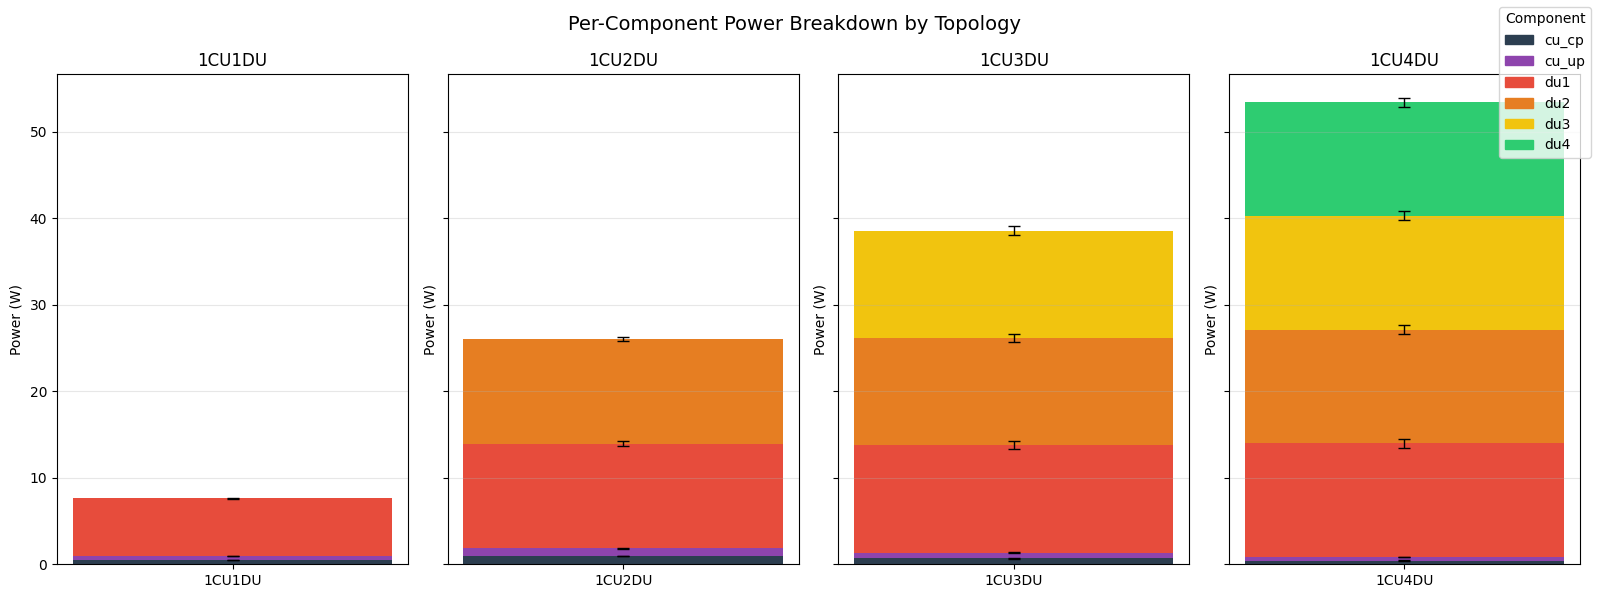

In [3]:
BREAKDOWN_TOPOLOGIES = sorted(breakdown['topology'].unique())
components_order = ['cu_cp', 'cu_up', 'du1', 'du2', 'du3', 'du4', 'du5']
comp_colors = {
    'cu_cp': '#2c3e50', 'cu_up': '#8e44ad',
    'du1': '#e74c3c', 'du2': '#e67e22',
    'du3': '#f1c40f', 'du4': '#2ecc71', 'du5': '#3498db'
}

fig, axes = plt.subplots(1, len(BREAKDOWN_TOPOLOGIES), figsize=(4*len(BREAKDOWN_TOPOLOGIES), 6), sharey=True)
if len(BREAKDOWN_TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, BREAKDOWN_TOPOLOGIES):
    subset = summary_breakdown[summary_breakdown['topology'] == topo]
    present = [c for c in components_order if c in subset['component'].values]
    subset = subset.set_index('component').reindex(present).reset_index()

    bottom = 0
    for _, row in subset.iterrows():
        ax.bar(
            topo.upper(), row['mean_W'],
            bottom=bottom,
            color=comp_colors[row['component']],
            label=row['component'],
            yerr=row['std_W'],
            error_kw={'capsize': 4, 'elinewidth': 1},
        )
        bottom += row['mean_W']

    ax.set_title(topo.upper())
    ax.set_ylabel('Power (W)')
    ax.grid(True, alpha=0.3, axis='y')

present_all = [c for c in components_order if c in summary_breakdown['component'].values]
handles = [plt.Rectangle((0,0),1,1, color=comp_colors[c]) for c in present_all]
fig.legend(handles, present_all, loc='upper right', title='Component')
plt.suptitle('Per-Component Power Breakdown by Topology', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/breakdown_stacked.png', dpi=150)
plt.show()

DU processing accounts for the dominant share of total RAN power across all topologies.
CU-CP and CU-UP together contribute less than 2W in all cases, confirming that the control
plane overhead is negligible relative to the distributed units. Per-DU power increases
slightly with the number of DUs, from 6.7W in 1CU-1DU to 13.1W in 1CU-4DU, suggesting
that each additional DU places a higher processing demand on the shared CPU resources.

## 2. Experiment Matrix: Power vs Load

Experiment results are loaded from JSON files in `docs/logs/matrix/`. Each file corresponds
to a single run of one topology/CQI/UE combination and contains raw power samples, mean and
standard deviation in Watts. Runs 4 and 5 for CQI=5 96UE are excluded due to thermal
instability observed during prolonged experiment sessions.

In [4]:
records = []
for f in glob.glob(f"{MATRIX_DIR}/power_*.json"):
    d = json.load(open(f))
    records.append({
        'topology': d['topology'],
        'nof_ues':  d['nof_ues'],
        'cqi':      d['cqi'],
        'run':      d['run'],
        'mean_W':   d['mean_W'],
        'std_W':    d['std_W'],
        'n':        d['n']
    })

df = pd.DataFrame(records)
print(f"Total records: {df.shape[0]}")
print(f"Topologies: {sorted(df['topology'].unique())}")
print(f"CQI values: {sorted(df['cqi'].unique())}")
print(f"UE values:  {sorted(df['nof_ues'].unique())}")
df.head()

Total records: 225
Topologies: ['1cu1du', '1cu2du', '1cu3du']
CQI values: [np.int64(5), np.int64(10), np.int64(15)]
UE values:  [np.int64(1), np.int64(4), np.int64(16), np.int64(64), np.int64(96)]


,topology,nof_ues,cqi,run,mean_W,std_W,n
0,1cu1du,4,5,5,3.426560,0.038043,30
1,1cu2du,1,15,2,12.039927,0.087539,30
2,1cu1du,64,5,1,4.885600,0.039728,30
3,1cu2du,64,5,3,16.735039,0.191848,30
4,1cu2du,96,10,3,15.117120,0.095506,30


In [5]:
# Exclude runs 4 and 5 for cqi=5 96UE (thermal instability)
mask = (df['cqi'] == 5) & (df['nof_ues'] == 96) & (df['run'] > 3)
df_clean = df[~mask].copy()
print(f"Records after cleaning: {df_clean.shape[0]} (removed {mask.sum()})")

summary = df_clean.groupby(['topology', 'cqi', 'nof_ues']).agg(
    mean_W=('mean_W', 'mean'),
    std_W=('mean_W', 'std'),
    runs=('run', 'count')
).reset_index()

# Dynamic topology config
TOPOLOGIES = sorted(summary['topology'].unique())
N = len(TOPOLOGIES)
palette = cm.get_cmap('tab10', N)
TOPO_COLORS = {topo: palette(i) for i, topo in enumerate(TOPOLOGIES)}
TOPO_MARKERS = {topo: m for topo, m in zip(TOPOLOGIES, ['o', 's', '^', 'D', 'v', 'P'])}
CQI_COLORS = {5: '#e74c3c', 10: '#3498db', 15: '#2ecc71'}

print(f"Topologies in matrix: {TOPOLOGIES}")
print(f"\nSummary sample:")
print(summary[summary['topology'] == TOPOLOGIES[0]].to_string())

Records after cleaning: 219 (removed 6)
Topologies in matrix: ['1cu1du', '1cu2du', '1cu3du']

Summary sample:
   topology  cqi  nof_ues    mean_W     std_W  runs
0    1cu1du    5        1  3.359057  0.028826     5
1    1cu1du    5        4  3.441994  0.017942     5
2    1cu1du    5       16  4.657706  0.022317     5
3    1cu1du    5       64  4.884421  0.008196     5
4    1cu1du    5       96  5.181811  0.027104     3
5    1cu1du   10        1  3.056625  0.015608     5
6    1cu1du   10        4  3.093711  0.014148     5
7    1cu1du   10       16  4.110814  0.005120     5
8    1cu1du   10       64  4.365323  0.004919     5
9    1cu1du   10       96  4.594113  0.010798     5
10   1cu1du   15        1  3.064025  0.005079     5
11   1cu1du   15        4  3.114661  0.007952     5
12   1cu1du   15       16  4.076139  0.012301     5
13   1cu1du   15       64  4.315051  0.006087     5
14   1cu1du   15       96  4.536812  0.018778     5


/tmp/ipykernel_12143/3990024709.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap('tab10', N)


Note: the experiment matrix covers topologies available in `docs/logs/matrix/`.
Additional topologies (e.g. 1CU-4DU, multi-CU) are planned on CloudLab hardware to avoid
thermal constraints observed on the local testbed. When new data is added, re-running this
notebook will include the new topologies automatically.

### 2.1 Power Consumption vs Number of UEs

Power consumption is plotted as a function of UE count for each topology and CQI value.
Error bars represent the standard deviation across runs.

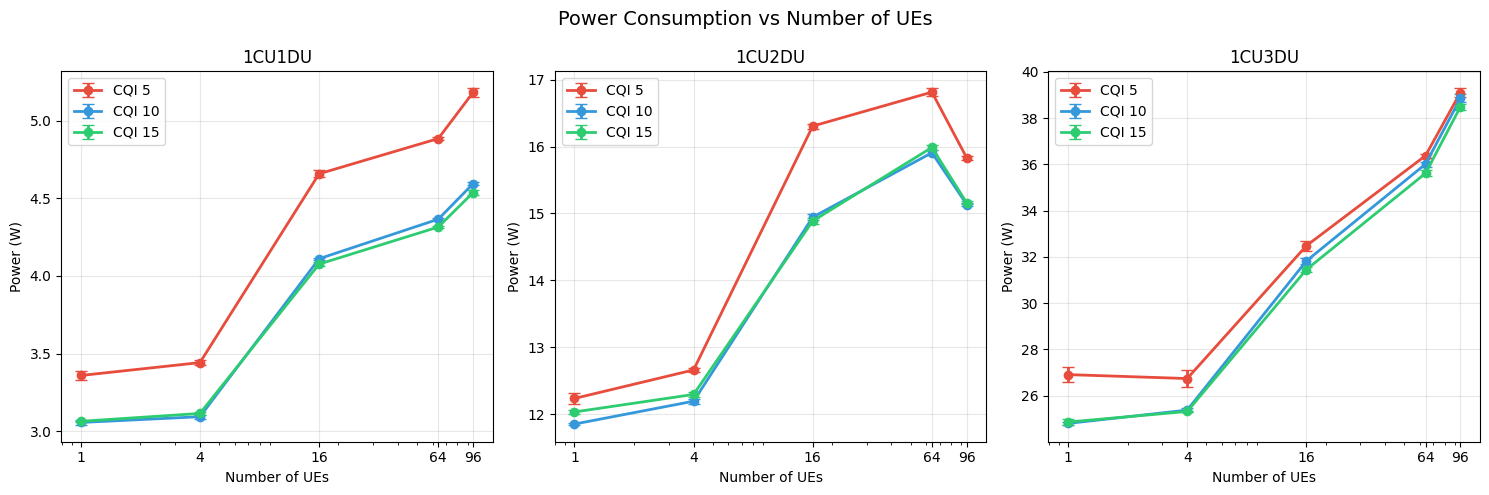

In [6]:
fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(5*len(TOPOLOGIES), 5), sharey=False)
if len(TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, TOPOLOGIES):
    for cqi, color in CQI_COLORS.items():
        subset = summary[(summary['topology'] == topo) & (summary['cqi'] == cqi)]
        ax.errorbar(
            subset['nof_ues'], subset['mean_W'], yerr=subset['std_W'],
            marker='o', label=f'CQI {cqi}', color=color, capsize=4, linewidth=2
        )
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Power (W)')
    ax.set_xscale('log')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Power Consumption vs Number of UEs', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/power_vs_ues.png', dpi=150)
plt.show()

Power consumption increases with UE count across all topologies and CQI values, with a
noticeable saturation effect beyond 64 UEs. CQI=5 consistently draws more power than
CQI=10 and CQI=15, reflecting increased DU processing load at lower channel quality.
CQI=10 and CQI=15 are nearly indistinguishable, suggesting a threshold effect above
which channel quality no longer drives energy consumption significantly.

### 2.2 Topology Comparison

Total power consumption is compared across topologies for each CQI value.
This highlights the fixed infrastructure cost introduced by each additional DU.

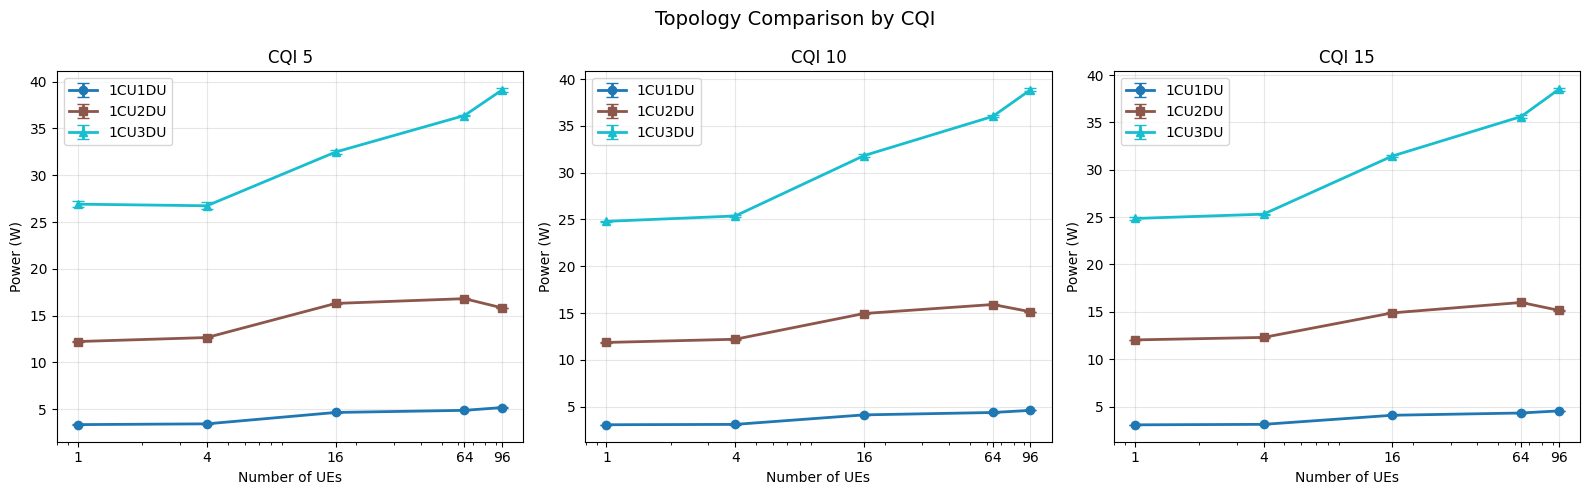

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, cqi in zip(axes, [5, 10, 15]):
    for topo in TOPOLOGIES:
        subset = summary[(summary['topology'] == topo) & (summary['cqi'] == cqi)]
        ax.errorbar(
            subset['nof_ues'], subset['mean_W'], yerr=subset['std_W'],
            marker=TOPO_MARKERS[topo], label=topo.upper(),
            color=TOPO_COLORS[topo], capsize=4, linewidth=2
        )
    ax.set_title(f'CQI {cqi}')
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Power (W)')
    ax.set_xscale('log')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Topology Comparison by CQI', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/topology_comparison.png', dpi=150)
plt.show()

The gap between topologies is largely constant across UE counts, confirming that the
dominant cost of adding a DU is a fixed infrastructure overhead rather than a
load-dependent effect.

### 2.3 Energy Efficiency: Power per UE

Power per UE is computed as total power divided by the number of active UEs.
This metric captures how efficiently the infrastructure is utilised as load increases.

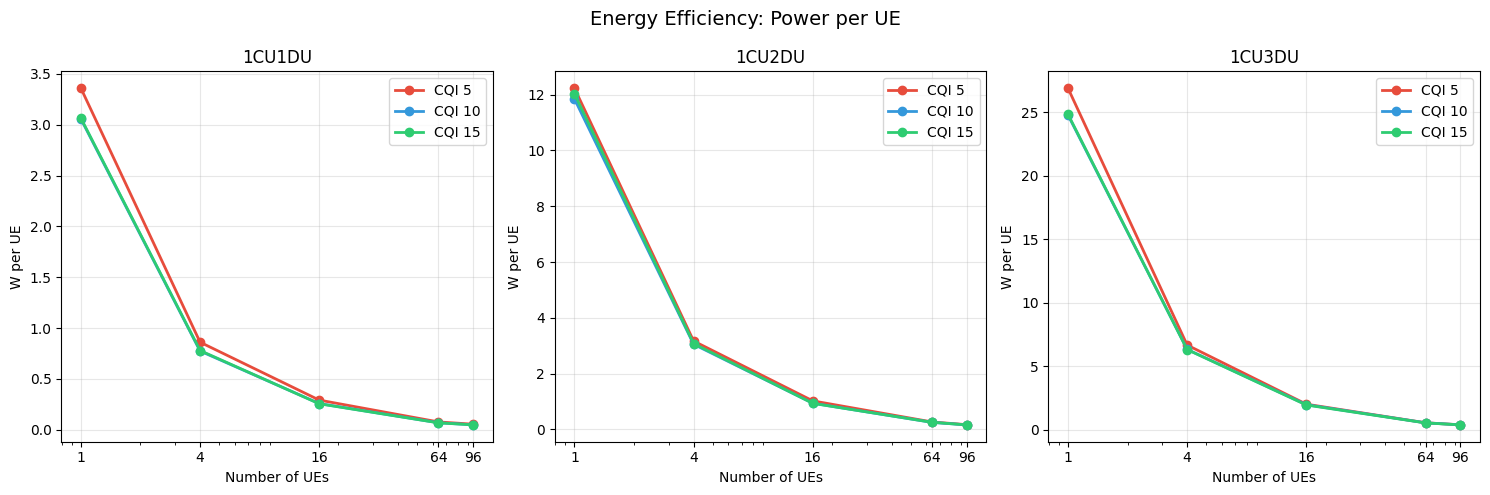

In [8]:
summary['W_per_UE'] = summary['mean_W'] / summary['nof_ues']

fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(5*len(TOPOLOGIES), 5), sharey=False)
if len(TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, TOPOLOGIES):
    for cqi, color in CQI_COLORS.items():
        subset = summary[(summary['topology'] == topo) & (summary['cqi'] == cqi)]
        ax.plot(
            subset['nof_ues'], subset['W_per_UE'],
            marker='o', label=f'CQI {cqi}', color=color, linewidth=2
        )
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('W per UE')
    ax.set_xscale('log')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Energy Efficiency: Power per UE', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/efficiency_W_per_UE.png', dpi=150)
plt.show()

Energy efficiency improves dramatically with increasing UE count across all topologies,
following a near-hyperbolic curve. At 1 UE, per-UE cost is dominated by fixed DU overhead.
At 96 UEs, all topologies converge towards low W/UE values, demonstrating effective
amortisation of fixed infrastructure costs at high load. CQI has negligible impact on per-UE efficiency.

### 2.4 Marginal Cost of Adding a DU

The marginal power cost of each additional DU is computed as the difference in total
power consumption between consecutive topologies at the same CQI and UE count.

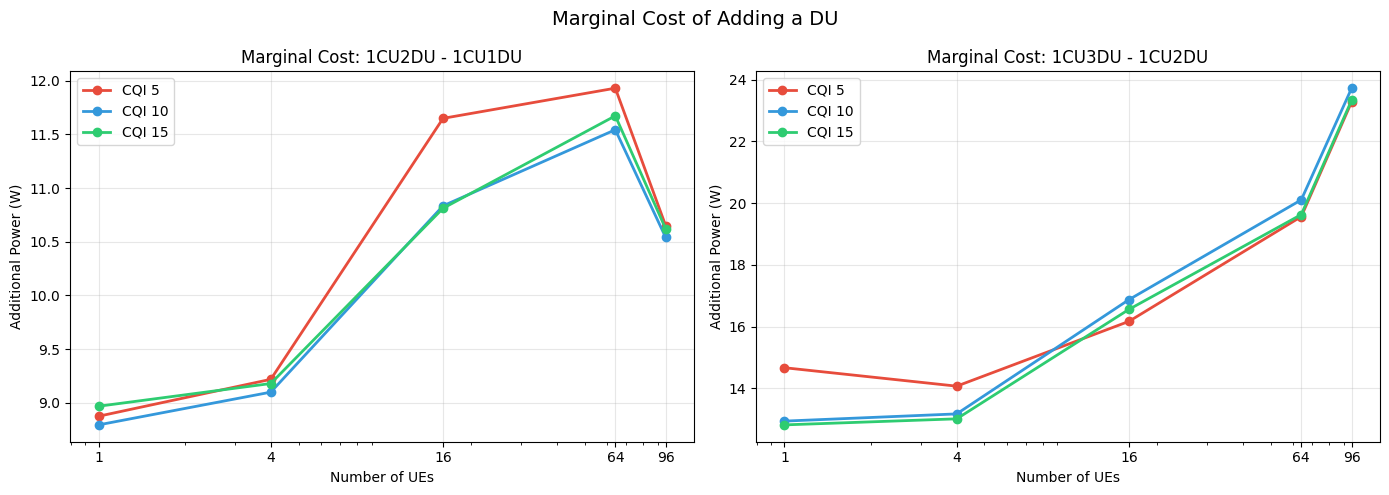

In [9]:
topo_pairs = [(TOPOLOGIES[i], TOPOLOGIES[i+1]) for i in range(len(TOPOLOGIES)-1)]

if topo_pairs:
    fig, axes = plt.subplots(1, len(topo_pairs), figsize=(7*len(topo_pairs), 5))
    if len(topo_pairs) == 1:
        axes = [axes]

    for ax, (t1, t2) in zip(axes, topo_pairs):
        label = f'{t2.upper()} - {t1.upper()}'
        for cqi, color in CQI_COLORS.items():
            s1 = summary[(summary['topology'] == t1) & (summary['cqi'] == cqi)].set_index('nof_ues')
            s2 = summary[(summary['topology'] == t2) & (summary['cqi'] == cqi)].set_index('nof_ues')
            delta = s2['mean_W'] - s1['mean_W']
            ax.plot(delta.index, delta.values, marker='o', label=f'CQI {cqi}', color=color, linewidth=2)

        ax.set_xlabel('Number of UEs')
        ax.set_ylabel('Additional Power (W)')
        ax.set_title(f'Marginal Cost: {label}')
        ax.set_xscale('log')
        ax.set_xticks([1, 4, 16, 64, 96])
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('Marginal Cost of Adding a DU', fontsize=14)
    plt.tight_layout()
    plt.savefig('../analysis/marginal_cost_du.png', dpi=150)
    plt.show()

The marginal cost of each additional DU is not constant: it increases with UE count,
suggesting that DU processing overhead scales with the number of active UEs up to a
saturation point. CQI has minimal influence on marginal cost.

### 2.5 Heatmap: Power Consumption Matrix (CQI x UEs)

The heatmap provides a compact view of the full experiment matrix, showing how power
consumption varies jointly with CQI and UE count for each topology.

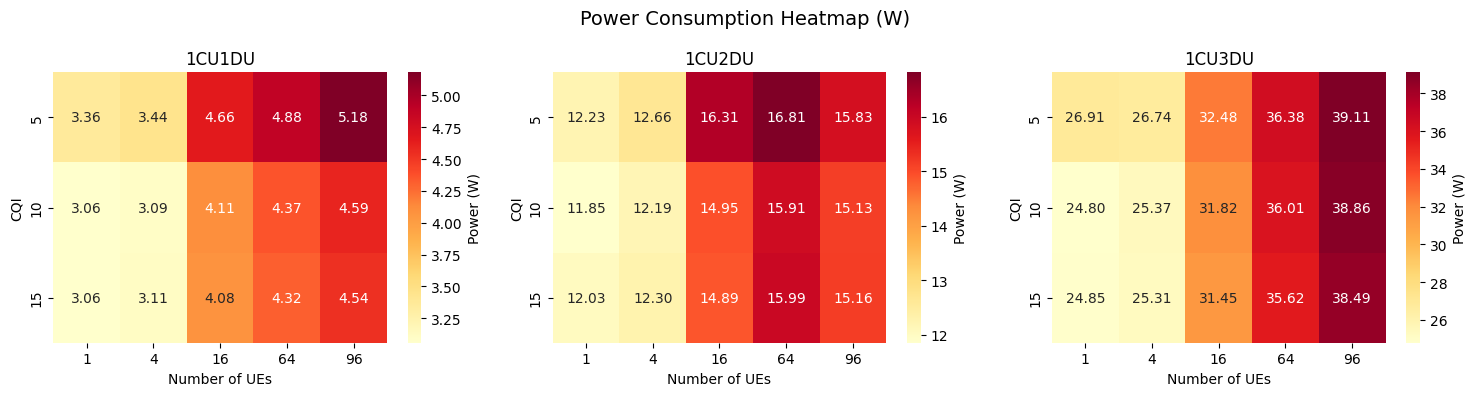

In [10]:
fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(5*len(TOPOLOGIES), 4))
if len(TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, TOPOLOGIES):
    pivot = summary[summary['topology'] == topo].pivot(
        index='cqi', columns='nof_ues', values='mean_W'
    )
    sns.heatmap(
        pivot, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
        cbar_kws={'label': 'Power (W)'}
    )
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('CQI')

plt.suptitle('Power Consumption Heatmap (W)', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/heatmap_cqi_ues.png', dpi=150)
plt.show()

The heatmaps confirm that UE count is the primary driver of power consumption across
all topologies, with CQI contributing a secondary effect concentrated at CQI=5.
The colour scale shifts significantly between topologies, reflecting the growing
baseline infrastructure cost as DU instances are added.

### 2.6 Run Variability: CQI=5 96UE

Per-run power distribution for the CQI=5 96UE combination, which showed thermal
instability in runs 4 and 5. This plot justifies their exclusion from the analysis.

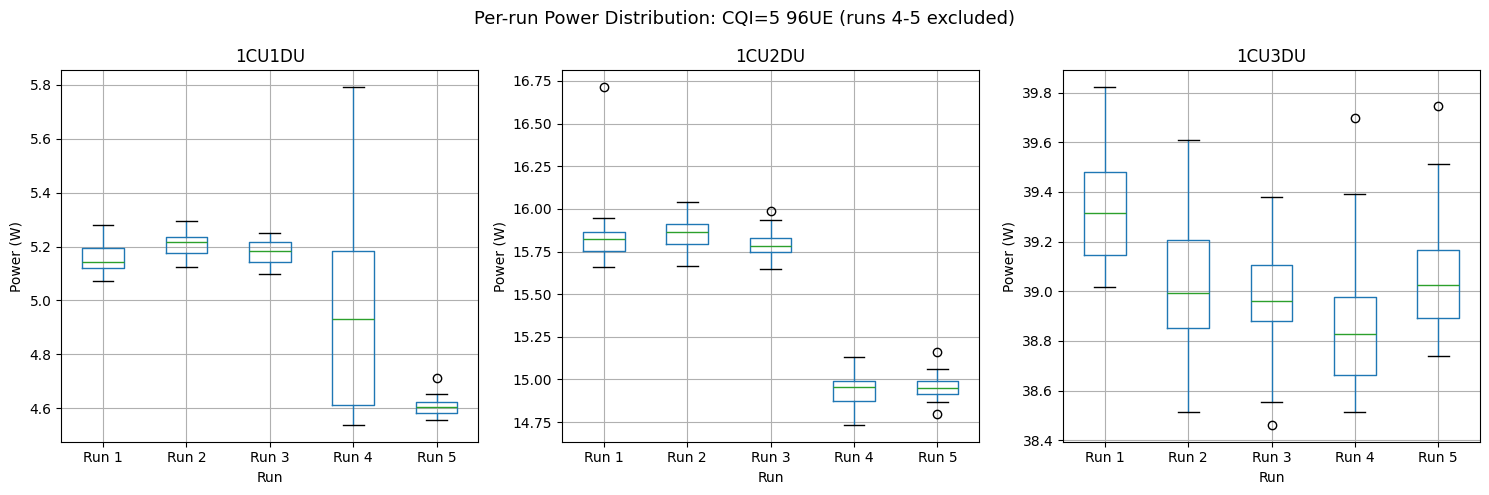

In [11]:
data_runs = []
for topo in TOPOLOGIES:
    for run in range(1, 6):
        f = f"{MATRIX_DIR}/power_{topo}_cqi5_96ue_run{run}.json"
        if os.path.exists(f):
            d = json.load(open(f))
            for s in d['samples']:
                data_runs.append({
                    'topology': topo.upper(),
                    'run': f'Run {run}',
                    'power_W': s,
                    'excluded': run > 3
                })

df_runs = pd.DataFrame(data_runs)

fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(5*len(TOPOLOGIES), 5), sharey=False)
if len(TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, [t.upper() for t in TOPOLOGIES]):
    subset = df_runs[df_runs['topology'] == topo]
    if not subset.empty:
        subset.boxplot(column='power_W', by='run', ax=ax)
    ax.set_title(topo)
    ax.set_xlabel('Run')
    ax.set_ylabel('Power (W)')

plt.suptitle('Per-run Power Distribution: CQI=5 96UE (runs 4-5 excluded)', fontsize=13)
plt.tight_layout()
plt.savefig('../analysis/boxplot_runs_cqi5_96ue.png', dpi=150)
plt.show()

Runs 4 and 5 show elevated power and increased variance relative to runs 1-3,
consistent with thermal throttling after prolonged experiment sessions. Their exclusion
is justified by the clear distributional shift visible in the boxplots.

### 2.7 Fixed vs Dynamic Power Overhead

To separate fixed infrastructure cost from load-dependent consumption, the power at 1 UE
is used as a baseline. The dynamic overhead represents the additional power drawn as the
number of UEs increases.

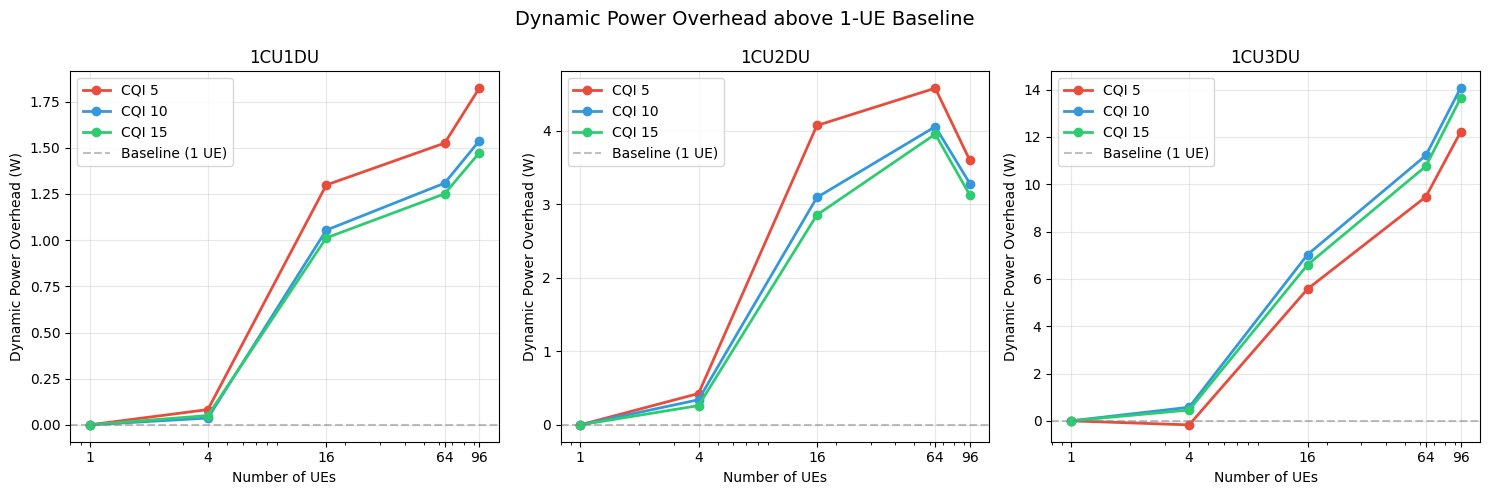

In [12]:
fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(5*len(TOPOLOGIES), 5), sharey=False)
if len(TOPOLOGIES) == 1:
    axes = [axes]

for ax, topo in zip(axes, TOPOLOGIES):
    for cqi, color in CQI_COLORS.items():
        subset = summary[(summary['topology'] == topo) & (summary['cqi'] == cqi)]
        fixed = subset[subset['nof_ues'] == 1]['mean_W'].values
        if len(fixed) == 0:
            continue
        dynamic = subset['mean_W'] - fixed[0]
        ax.plot(subset['nof_ues'], dynamic, marker='o', label=f'CQI {cqi}', color=color, linewidth=2)

    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Baseline (1 UE)')
    ax.set_title(topo.upper())
    ax.set_xlabel('Number of UEs')
    ax.set_ylabel('Dynamic Power Overhead (W)')
    ax.set_xscale('log')
    ax.set_xticks([1, 4, 16, 64, 96])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Dynamic Power Overhead above 1-UE Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('../analysis/dynamic_overhead.png', dpi=150)
plt.show()

Dynamic overhead increases with UE count in all topologies, driven primarily by
DU processing load. The overhead is more pronounced at CQI=5, consistent with increased
retransmission and scheduling activity at lower channel quality. The fixed infrastructure
cost, represented by the 1-UE baseline, accounts for the majority of total consumption
at low load.

### 2.8 Summary Table (LaTeX-ready)

Mean power consumption (W) with standard deviation for each topology, CQI, and UE count combination.

In [13]:
for topo in TOPOLOGIES:
    print(f"\n{'='*60}")
    print(f"{topo.upper()}")
    print('='*60)
    pivot = summary[summary['topology'] == topo].pivot(
        index='cqi', columns='nof_ues', values='mean_W'
    )
    pivot_std = summary[summary['topology'] == topo].pivot(
        index='cqi', columns='nof_ues', values='std_W'
    )
    print(pivot.to_string())

    print("\nLaTeX:")
    print("\\begin{tabular}{|c|" + "c|" * len(pivot.columns) + "}")
    print("\\hline")
    print("CQI & " + " & ".join([f"{c} UE" for c in pivot.columns]) + " \\\\")
    print("\\hline")
    for cqi in pivot.index:
        row = " & ".join([
            f"{pivot.loc[cqi, ue]:.2f} ({pivot_std.loc[cqi, ue]:.2f})"
            for ue in pivot.columns
        ])
        print(f"{cqi} & {row} \\\\")
    print("\\hline")
    print("\\end{tabular}")


1CU1DU
nof_ues        1         4         16        64        96
cqi                                                      
5        3.359057  3.441994  4.657706  4.884421  5.181811
10       3.056625  3.093711  4.110814  4.365323  4.594113
15       3.064025  3.114661  4.076139  4.315051  4.536812

LaTeX:
\begin{tabular}{|c|c|c|c|c|c|}
\hline
CQI & 1 UE & 4 UE & 16 UE & 64 UE & 96 UE \\
\hline
5 & 3.36 (0.03) & 3.44 (0.02) & 4.66 (0.02) & 4.88 (0.01) & 5.18 (0.03) \\
10 & 3.06 (0.02) & 3.09 (0.01) & 4.11 (0.01) & 4.37 (0.00) & 4.59 (0.01) \\
15 & 3.06 (0.01) & 3.11 (0.01) & 4.08 (0.01) & 4.32 (0.01) & 4.54 (0.02) \\
\hline
\end{tabular}

1CU2DU
nof_ues         1          4          16         64         96
cqi                                                           
5        12.234938  12.661523  16.306268  16.813911  15.830386
10       11.852188  12.193983  14.945068  15.907931  15.133785
15       12.033126  12.295283  14.887745  15.987042  15.157109

LaTeX:
\begin{tabular}{|c|c|c|c|